
# README:

# Customer Churn Prediction using Gradient Boosting Ensemble

This notebook focuses on predicting customer churn using multiple Gradient Boosting Decision Tree (GBDT) models and ensemble learning techniques. The project includes data preprocessing, feature engineering, feature importance analysis, model evaluation, and weighted soft-voting ensemble methods.

The final solution combines:
- GradientBoostingClassifier
- XGBoost
- LightGBM

using a weighted ensemble strategy to improve overall ROC-AUC performance.

---

## Project Workflow

### 1. Data Preprocessing
- Missing value handling
- Label encoding for categorical features
- Feature scaling techniques
- Train-validation split

### 2. Feature Engineering
Several feature engineering techniques were applied, including:
- Frequency-based features
- Categorical encoding
- Distribution difference checking between train and test datasets
- Feature importance analysis

Special attention was given to high-cardinality categorical features such as `Surname`, because train-test distribution drift may cause overfitting.

### 3. Model Training
Three tree-based boosting models were trained:

- GradientBoostingClassifier
- XGBoost Classifier
- LightGBM Classifier

Each model was evaluated independently using:
- ROC-AUC
- Validation metrics
- Binary classification evaluation

### 4. Ensemble Learning
A weighted soft-voting ensemble was used to combine model probabilities:

```python
pred_avg = (
    0.4 * y_pred1 +
    0.34 * y_pred2 +
    0.26 * y_pred3
)
```


###  Feature Importance Comparison

Feature importance scores from all three models were compared to analyze:

Shared important features
Model-specific patterns
Potential overfitting risks
Evaluation Metric

### The primary evaluation metric is:

ROC-AUC Score

because churn prediction is a binary classification problem with probability-based evaluation.

### Key Techniques Used
Gradient Boosting Decision Trees (GBDT)
Weighted Soft Voting Ensemble
Feature Scaling
Feature Importance Analysis
Distribution Shift Detection

### Conclusion

This notebook demonstrates how combining multiple boosting models through weighted ensemble learning can improve churn prediction performance. It also highlights the importance of analyzing feature distribution differences and avoiding overfitting caused by high-cardinality categorical variables.

The final ensemble achieved stronger and more stable ROC-AUC performance compared with individual models.



#  Import libraries

In [58]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/binary-battle-ml-bank-customer-churn-challenge/sample_submission.csv
/kaggle/input/binary-battle-ml-bank-customer-churn-challenge/train.csv
/kaggle/input/binary-battle-ml-bank-customer-churn-challenge/test.csv


# 1. Load data

In [59]:
train = pd.read_csv("/kaggle/input/binary-battle-ml-bank-customer-churn-challenge/train.csv")
test  = pd.read_csv("/kaggle/input/binary-battle-ml-bank-customer-churn-challenge/test.csv")



# 2. Data Overview

In [45]:
print(train.shape, test.shape)
train.head()

(165034, 14) (110023, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [6]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,165034.0,NaN,NaN,NaN,82516.5,47641.3565,0.0,41258.25,82516.5,123774.75,165033.0
CustomerId,165034.0,NaN,NaN,NaN,15692005.019026,71397.816791,15565701.0,15633141.0,15690169.0,15756824.0,15815690.0
Surname,165034,2797,Hsia,2456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,165034.0,NaN,NaN,NaN,656.454373,80.10334,350.0,597.0,659.0,710.0,850.0
Geography,165034,3,France,94215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,165034,2,Male,93150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,165034.0,NaN,NaN,NaN,38.125888,8.867205,18.0,32.0,37.0,42.0,92.0
Tenure,165034.0,NaN,NaN,NaN,5.020353,2.806159,0.0,3.0,5.0,7.0,10.0
Balance,165034.0,NaN,NaN,NaN,55478.086689,62817.663278,0.0,0.0,0.0,119939.5175,250898.09
NumOfProducts,165034.0,NaN,NaN,NaN,1.554455,0.547154,1.0,1.0,2.0,2.0,4.0


In [60]:
test.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,110023.0,NaN,NaN,NaN,220045.0,31761.048671,165034.0,192539.5,220045.0,247550.5,275056.0
CustomerId,110023.0,NaN,NaN,NaN,15692096.605101,71684.990992,15565701.0,15632859.0,15690175.0,15756926.0,15815690.0
Surname,110023,2708,Hsia,1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,110023.0,NaN,NaN,NaN,656.530789,80.315415,350.0,597.0,660.0,710.0,850.0
Geography,110023,3,France,63171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,110023,2,Male,61942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,110023.0,NaN,NaN,NaN,38.122205,8.86155,18.0,32.0,37.0,42.0,92.0
Tenure,110023.0,NaN,NaN,NaN,4.996637,2.806148,0.0,3.0,5.0,7.0,10.0
Balance,110023.0,NaN,NaN,NaN,55333.611354,62788.519675,0.0,0.0,0.0,120145.605,250898.09
NumOfProducts,110023.0,NaN,NaN,NaN,1.553321,0.544714,1.0,1.0,2.0,2.0,4.0


Feature groups

The dataset includes numerical features (e.g., Age, Balance, CreditScore), 

binary indicators (e.g., HasCrCard, IsActiveMember), 

and categorical features encoded as integers (Geography, Gender).


In [61]:
#Target overview
train["Exited"].value_counts(normalize=True)

Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64

In [62]:

def compare_train_test(train, test, target_col=None):
    
    results = []
    
    for col in train.columns:
        
        if col == target_col:
            continue
        
        # check type
        if train[col].dtype in ['int64', 'float64']:
            
            #  KS test
            stat, p_value = ks_2samp(
                train[col].dropna(),
                test[col].dropna()
            )
            
            results.append({
                'feature': col,
                'type': 'numerical',
                'metric': 'KS test',
                'value': stat,
                'p_value': p_value
            })
        
        else:
            # distribution diff
            train_dist = train[col].value_counts(normalize=True)
            test_dist = test[col].value_counts(normalize=True)
            
            # index
            all_index = train_dist.index.union(test_dist.index)
            train_dist = train_dist.reindex(all_index, fill_value=0)
            test_dist = test_dist.reindex(all_index, fill_value=0)
            
            diff = np.abs(train_dist - test_dist).sum()
            
            results.append({
                'feature': col,
                'type': 'categorical',
                'metric': 'distribution diff',
                'value': diff,
                'p_value': np.nan
            })
    
    return pd.DataFrame(results)
    

In [63]:
def add_flag(df):
    
    flags = []
    
    for _, row in df.iterrows():
        
        if row['type'] == 'numerical':
            flags.append('OK' if row['p_value'] > 0.05 else 'DIFF')
        else:
            flags.append('OK' if row['value'] < 0.1 else 'DIFF')
    
    df['flag'] = flags
    return df

In [64]:
result_df = compare_train_test(train, test, target_col='Exited')
result_df = add_flag(result_df)

print(result_df.sort_values(by='value', ascending=False))

            feature         type             metric     value   p_value  flag
0                id    numerical            KS test  1.000000  0.000000  DIFF
2           Surname  categorical  distribution diff  0.110944       NaN  DIFF
4         Geography  categorical  distribution diff  0.006559       NaN    OK
7            Tenure    numerical            KS test  0.004900  0.083723    OK
12  EstimatedSalary    numerical            KS test  0.003637  0.345981    OK
1        CustomerId    numerical            KS test  0.003208  0.504135    OK
5            Gender  categorical  distribution diff  0.002876       NaN    OK
3       CreditScore    numerical            KS test  0.002664  0.735662    OK
11   IsActiveMember    numerical            KS test  0.002537  0.788020    OK
6               Age    numerical            KS test  0.002274  0.883655    OK
8           Balance    numerical            KS test  0.002131  0.924621    OK
9     NumOfProducts    numerical            KS test  0.001163  0

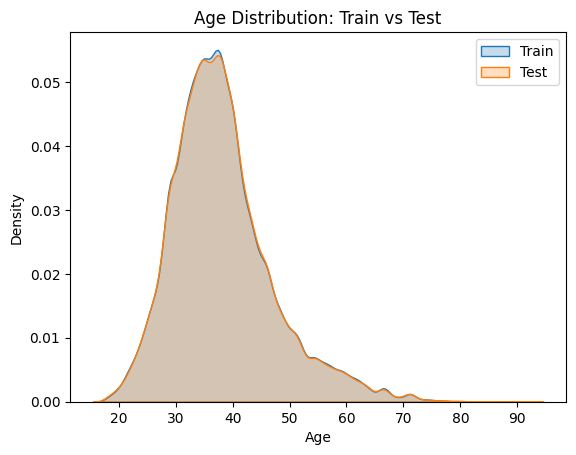

In [65]:
plt.figure()
sns.kdeplot(train['Age'], label='Train', fill=True)
sns.kdeplot(test['Age'], label='Test', fill=True)

plt.legend()
plt.title("Age Distribution: Train vs Test")
plt.show()

In [ ]:
plt.figure()
sns.kdeplot(train['Age'], label='Train', fill=True)
sns.kdeplot(test['Age'], label='Test', fill=True)

plt.legend()
plt.title("Age Distribution: Train vs Test")
plt.show()

In [ ]:
df = pd.DataFrame({
    'Train': train['Gender'].value_counts(normalize=True),
    'Test': test['Gender'].value_counts(normalize=True)
})

df.plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    pd.concat([train['Gender'], test['Gender']]),
    ['Train']*len(train) + ['Test']*len(test)
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

In [ ]:
# Gender: Male shows a lower curn rate
train.groupby("Gender")["Exited"].mean().plot(
    kind="bar",
    title="Churn Rate by Gender",
    ylabel="Churn Rate"
)

In [ ]:
# Missing values check
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())



The dataset does not contain missing values.
Statistical checks show that all numerical features fall within reasonable business ranges.
No obvious abnormal or invalid values are observed, so no outlier removal is applied.

Logical validation checks were applied to binary and state-related features, including HasCrCard, IsActiveMember, Age, and Tenure.
All values fall within valid business ranges.
Relationships between activity status, product usage, and churn were analyzed as predictive signals rather than hard constraints.

In [ ]:
#No strong multicollinearity is observed among numerical features
import seaborn as sns

plt.figure()
sns.heatmap(
    train.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
corr_series = (
    train
    .select_dtypes(include="number")
    .corr()["Exited"]
    .drop("Exited")
)

# Sort by absolute value, but keep original values
corr_sorted = corr_series.reindex(
    corr_series.abs().sort_values(ascending=False).index
)

#print(corr_sorted)
plt.figure(figsize=(8, 5))
corr_sorted.plot(kind="barh")
plt



# 3. Merge train and test

In [66]:
train['is_train'] = 1
test['is_train'] = 0

#X_train = train.drop(columns=['Exited'])
test['Exited']=np.nan
all_data = pd.concat([train, test], axis=0).reset_index(drop=True)
all_data.head()



,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,is_train
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0.0,1
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0.0,1
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0.0,1
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0.0,1
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0.0,1


# 4. Feature Engineering & Encode categorical features (simple & safe)

In [67]:

#✅ Cross Feature 1

all_data["SingleProduct"] = (all_data["NumOfProducts"] == 1).astype(int)
# ✅ Cross Feature 2

all_data["CardButInactive"] = ((all_data["HasCrCard"] == 1) & (all_data["IsActiveMember"] == 0)).astype(int)

# ✅ Cross Feature 3

all_data["ZeroBalance"] = (all_data["Balance"] == 0).astype(int)

# ✅ Cross Feature 4
if 'Balance' in all_data.columns and 'NumOfProducts' in all_data.columns:
    all_data['Balance_Per_Product'] = all_data['Balance'] / all_data['NumOfProducts']

# ✅ process surname
all_data['Surname_prefix'] = all_data['Surname'].str[:5]
all_data['Surname_len'] = all_data['Surname'].str.len()
all_data['Surname_freq'] = all_data['Surname'].map(all_data['Surname'].value_counts())

In [68]:
# encoding....

# Copy data
all_data_new = all_data.copy()

# 1. One-hot only for low-cardinality categorical features
low_card_cols = ['Geography', 'Gender']

all_data_new = pd.get_dummies(
    all_data_new,
    columns=low_card_cols,
    drop_first=False
)

# 2. Frequency encoding for Surname_prefix
prefix_freq = all_data['Surname_prefix'].value_counts()

all_data_new['Surname_prefix_freq'] = all_data_new['Surname_prefix'].map(prefix_freq)

# 3. Drop raw text columns
drop_cols = ['Surname', 'Surname_prefix']

#all_data_new = all_data_new.drop(columns=drop_cols)

#encoding...
for col in ['Surname', 'Surname_prefix']:
    le = LabelEncoder()
    all_data_new[col] = le.fit_transform(all_data_new[col])
    

# 4. Drop ID Surname columns before modeling 
all_data_encoded = all_data_new.drop(columns=['id', 'CustomerId', 'Surname'])

In [12]:
all_data_encoded.head()

,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,...,Balance_Per_Product,Surname_prefix,Surname_len,Surname_freq,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Surname_prefix_freq
0,1992,668,33.0,3,0.00,2,1.0,0.0,181449.97,0.0,...,0.00,1714,14,439,True,False,False,False,True,978
1,1993,627,33.0,1,0.00,2,1.0,1.0,49503.50,0.0,...,0.00,1714,13,539,True,False,False,False,True,978
2,1217,678,40.0,10,0.00,2,1.0,0.0,184866.69,0.0,...,0.00,1034,5,2178,True,False,False,False,True,2178
3,1341,581,34.0,2,148882.54,1,1.0,1.0,84560.88,0.0,...,148882.54,1144,3,2577,True,False,False,False,True,2577
4,483,716,33.0,5,0.00,2,1.0,1.0,15068.83,0.0,...,0.00,402,9,379,False,False,True,False,True,641


Feature engineering was performed by creating a small number of cross-features based on product usage and customer activity, such as single-product status, inactive card holders, and zero-balance customers.
These features capture customer engagement patterns without introducing data leakage.

EstimatedSalary

✔ Missing values

✔ Abnormal values

✔ Logical consistency

✔ Business reasoning

✔ encoding 
(Geography and Gender are categorical features encoded as integer labels.
They are treated as categorical identifiers rather than ordinal numerical values.)
correlation

### Samples:
The dataset contains approximately 165k training samples with numerical and categorical features related to customer demographics and account activity. The target variable (Exited) is moderately imbalanced, with around 21% positive class.


# 5. Train / validation split

In [85]:
train_processed = all_data_encoded[all_data_encoded['is_train'] == 1].copy()
test_processed  = all_data_encoded[all_data_encoded['is_train'] == 0].copy()

y = train_processed['Exited']

X = train_processed.drop(columns=['Exited', 'is_train'])
X_test = test_processed.drop(columns=['Exited', 'is_train'])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

, 'Surname'

# 6. Modeling (Gradient Boosting)

In [71]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate_binary_classifier(y_true, y_pred_proba, threshold=0.5):
    """
    Evaluate binary classification results using accuracy and confusion matrix.

    Parameters
    ----------
    y_true : array-like
        True labels (0/1)
    y_pred_proba : array-like
        Predicted probabilities for class 1
    threshold : float, default=0.5
        Decision threshold for converting probability to class label

    Returns: print
    -------
    acc : float
        Accuracy score
    cm_df : pd.DataFrame
        Confusion matrix as a DataFrame
    """
    print(f"\n\nThreshold = {threshold}")
    # convert probability to label
    y_pred_label = (y_pred_proba >= threshold).astype(int)
    
    # accuracy
    acc = accuracy_score(y_true, y_pred_label)
    print("Accuracy:", acc)
    
    # confusion matrix
    cm = confusion_matrix(y_true, y_pred_label)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0 (Stay)", "Actual 1 (Exit)"],
        columns=["Pred 0 (Stay)", "Pred 1 (Exit)"]
    )
    print(cm_df)
    
    #return acc, cm_df


In [73]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=3000,
        learning_rate=0.025,
        max_depth=4,
        subsample=0.8,
        max_features=0.8,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=3000,
        learning_rate=0.02,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        early_stopping_rounds=100,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.02,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        random_state=42,
        n_jobs=-1
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

In [74]:
results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "XGBoost":
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

    elif name == "LightGBM":
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="auc"
        )

    else:
        model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    results.append({
        "model": name,
        "AUC": auc
    })

    trained_models[name] = model

    print(f"{name} AUC: {auc:.5f}")


Training RandomForest...
RandomForest AUC: 0.88976

Training GradientBoosting...
GradientBoosting AUC: 0.89531

Training XGBoost...
XGBoost AUC: 0.89522

Training LightGBM...
[LightGBM] [Info] Number of positive: 27937, number of negative: 104090
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1860
[LightGBM] [Info] Number of data points in the train set: 132027, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.211601 -> initscore=-1.315304
[LightGBM] [Info] Start training from score -1.315304
LightGBM AUC: 0.89431

Training LogisticRegression...
LogisticRegression AUC: 0.74598


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False)

print(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\nBest model:", best_model_name)
print("Best AUC:", results_df.iloc[0]["AUC"])

                model       AUC
1    GradientBoosting  0.895305
2             XGBoost  0.895223
3            LightGBM  0.894313
0        RandomForest  0.889757
4  LogisticRegression  0.745979

Best model: GradientBoosting
Best AUC: 0.8953050013603703


In [81]:
# Weighted Average Ensemble:　because Ｉ combine predictions from multiple models using different weights
y_pred1 = trained_models["GradientBoosting"].predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred1)
print(f"Ensemble AUC: {auc:.5f}")
evaluate_binary_classifier(y_val, y_pred1, 0.5)


y_pred2 = trained_models["XGBoost"].predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred2)
print(f"XGBoost AUC: {auc:.5f}")
evaluate_binary_classifier(y_val, y_pred2, 0.5)

y_pred3 = trained_models["LightGBM"].predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred3)
print(f"LightGBM AUC: {auc:.5f}")
evaluate_binary_classifier(y_val, y_pred3, 0.5)

# Average predictions
pred_avg = 0.4 * y_pred1 + 0.34 * y_pred2 + 0.26 * y_pred3

# Calculate AUC
auc = roc_auc_score(y_val, pred_avg)

print(f"Ensemble AUC: {auc:.5f}")
evaluate_binary_classifier(y_val, pred_avg, 0.5)







Ensemble AUC: 0.89531


Threshold = 0.5
Accuracy: 0.8689671887781379
                 Pred 0 (Stay)  Pred 1 (Exit)
Actual 0 (Stay)          24759           1264
Actual 1 (Exit)           3061           3923
XGBoost AUC: 0.89522


Threshold = 0.5
Accuracy: 0.8678462144393614
                 Pred 0 (Stay)  Pred 1 (Exit)
Actual 0 (Stay)          24723           1300
Actual 1 (Exit)           3062           3922
LightGBM AUC: 0.89431


Threshold = 0.5
Accuracy: 0.8684521465143757
                 Pred 0 (Stay)  Pred 1 (Exit)
Actual 0 (Stay)          24748           1275
Actual 1 (Exit)           3067           3917
Ensemble AUC: 0.89573


Threshold = 0.5
Accuracy: 0.8686339261368801
                 Pred 0 (Stay)  Pred 1 (Exit)
Actual 0 (Stay)          24756           1267
Actual 1 (Exit)           3069           3915


In [87]:
#　train again using all data
trained_models["GradientBoosting"].fit(X, y)
trained_models["XGBoost"].fit(
            X,
            y,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
trained_models["LightGBM"].fit(
            X,
            y,
            eval_set=[(X_val, y_val)],
            eval_metric="auc"
        )

[LightGBM] [Info] Number of positive: 34921, number of negative: 130113
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1858
[LightGBM] [Info] Number of data points in the train set: 165034, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.211599 -> initscore=-1.315315
[LightGBM] [Info] Start training from score -1.315315


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.02, n_estimators=3000,
               n_jobs=-1, objective='binary', random_state=42, subsample=0.8)

# 7. Create submission

In [83]:
# submit result
y_pred1 = trained_models["GradientBoosting"].predict_proba(X_test)[:, 1]

y_pred2 = trained_models["XGBoost"].predict_proba(X_test)[:, 1]

y_pred3 = trained_models["LightGBM"].predict_proba(X_test)[:, 1]

# Average predictions
pred_avg = 0.4 * y_pred1 + 0.34 * y_pred2 + 0.26 * y_pred3

ID_COL = "id"   # change if different

test_pred_adj = pred_avg.copy()



submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    'Exited': test_pred_adj
})

# this result's accuracy maybe is a little higher than the below submission1, but its AUC maybe a little lower than the below
submission.to_csv("submission.csv", index=False)
submission.head()

### Clear Evaluation Metrics justification
AUC was used as the primary metric to evaluate ranking performance under class imbalance, while accuracy and confusion matrices were used to analyze decision-level performance under different thresholds.

# 8. Feature Importance

In [22]:
y_pred1 = trained_models["GradientBoosting"].predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred1)
evaluate_binary_classifier(y_val, y_pred1, 0.5)

y_pred2 = trained_models["XGBoost"].predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred2)
print(f"XGBoost AUC: {auc:.5f}")
evaluate_binary_classifier(y_val, y_pred2, 0.5)

y_pred3 = trained_models["LightGBM"].predict_proba(X_val)[:, 1]
# Get feature importance from each model
gb_importance = pd.Series(
    trained_models["GradientBoosting"].feature_importances_,
    index=X_train.columns,
    name="GradientBoosting"
).sort_values(ascending=False).reset_index()

xgb_importance = pd.Series(
    trained_models["XGBoost"].feature_importances_,
    index=X_train.columns,
    name="XGBoost"
).sort_values(ascending=False).reset_index()

lgbm_importance = pd.Series(
    trained_models["LightGBM"].feature_importances_,
    index=X_train.columns,
    name="LightGBM"
).sort_values(ascending=False).reset_index()

# Combine together
feature_compare = pd.concat(
    [gb_importance, xgb_importance, lgbm_importance],
    axis=1
)



print(feature_compare)


                  index  GradientBoosting                index   XGBoost  \
0                   Age          0.314228        SingleProduct  0.301602   
1         NumOfProducts          0.196040        NumOfProducts  0.206110   
2        IsActiveMember          0.080093       IsActiveMember  0.099959   
3         SingleProduct          0.077881          ZeroBalance  0.087519   
4   Balance_Per_Product          0.050077                  Age  0.082158   
5               Balance          0.045346    Geography_Germany  0.043594   
6       EstimatedSalary          0.037894        Gender_Female  0.031294   
7     Geography_Germany          0.034470          Gender_Male  0.027456   
8           CreditScore          0.027130      CardButInactive  0.021078   
9          Surname_freq          0.022491  Balance_Per_Product  0.018376   
10  Surname_prefix_freq          0.020236     Geography_France  0.013864   
11              Surname          0.018757              Balance  0.011354   
12       Sur

# 9. Conclusion
This notebook demonstrates a complete churn modeling pipeline including feature engineering, model training, and cross-validation. Simple, interpretable features combined with Gradient Boosting achieve stable performance without overfitting.

## Business Interpretation

This model can be used to identify customers with high churn risk.
By targeting these customers with retention strategies,
the company can reduce customer loss and improve revenue stability.


### Limitations and Next Steps

This analysis focuses on offline churn prediction using historical data and a random train–validation split. In a production environment, a time-based validation strategy would be preferred.

The decision threshold was selected based on validation performance; however, the optimal threshold would ultimately depend on business-specific costs associated with different types of classification errors.

Future work could incorporate cost-sensitive learning and probability calibration to further align model decisions with real-world business objectives.
